In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import faiss
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['axes.edgecolor'] = '#333'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['axes.labelcolor'] = '#e0e0e0'
plt.rcParams['xtick.color'] = '#888'
plt.rcParams['ytick.color'] = '#888'
plt.rcParams['grid.color'] = '#2a2a2a'

print('Imports prontos')

Matplotlib is building the font cache; this may take a moment.
/Users/kellyleticiamorais/Documents/recsys-fashion/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Imports prontos


In [2]:
with open('../data/produtos.json', encoding='utf-8') as f:
    produtos = json.load(f)

df = pd.DataFrame(produtos)

print(f'Total de produtos: {len(df):,}')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nPrimeiras linhas:')
df.head(3)

Total de produtos: 44,417

Colunas: ['id', 'productDisplayName', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage', 'link', 'texto_embedding']

Primeiras linhas:


,id,productDisplayName,gender,masterCategory,subCategory,articleType,baseColour,season,usage,link,texto_embedding
0,15970,Turtle Check Men Navy Blue Shirt,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,Casual,http://assets.myntassets.com/v1/images/style/p...,Turtle Check Men Navy Blue Shirt Shirts Topwea...
1,39386,Peter England Men Party Blue Jeans,Men,Apparel,Bottomwear,Jeans,Blue,Summer,Casual,http://assets.myntassets.com/v1/images/style/p...,Peter England Men Party Blue Jeans Jeans Botto...
2,59263,Titan Women Silver Watch,Women,Accessories,Watches,Watches,Silver,Winter,Casual,http://assets.myntassets.com/v1/images/style/p...,Titan Women Silver Watch Watches Watches Women...


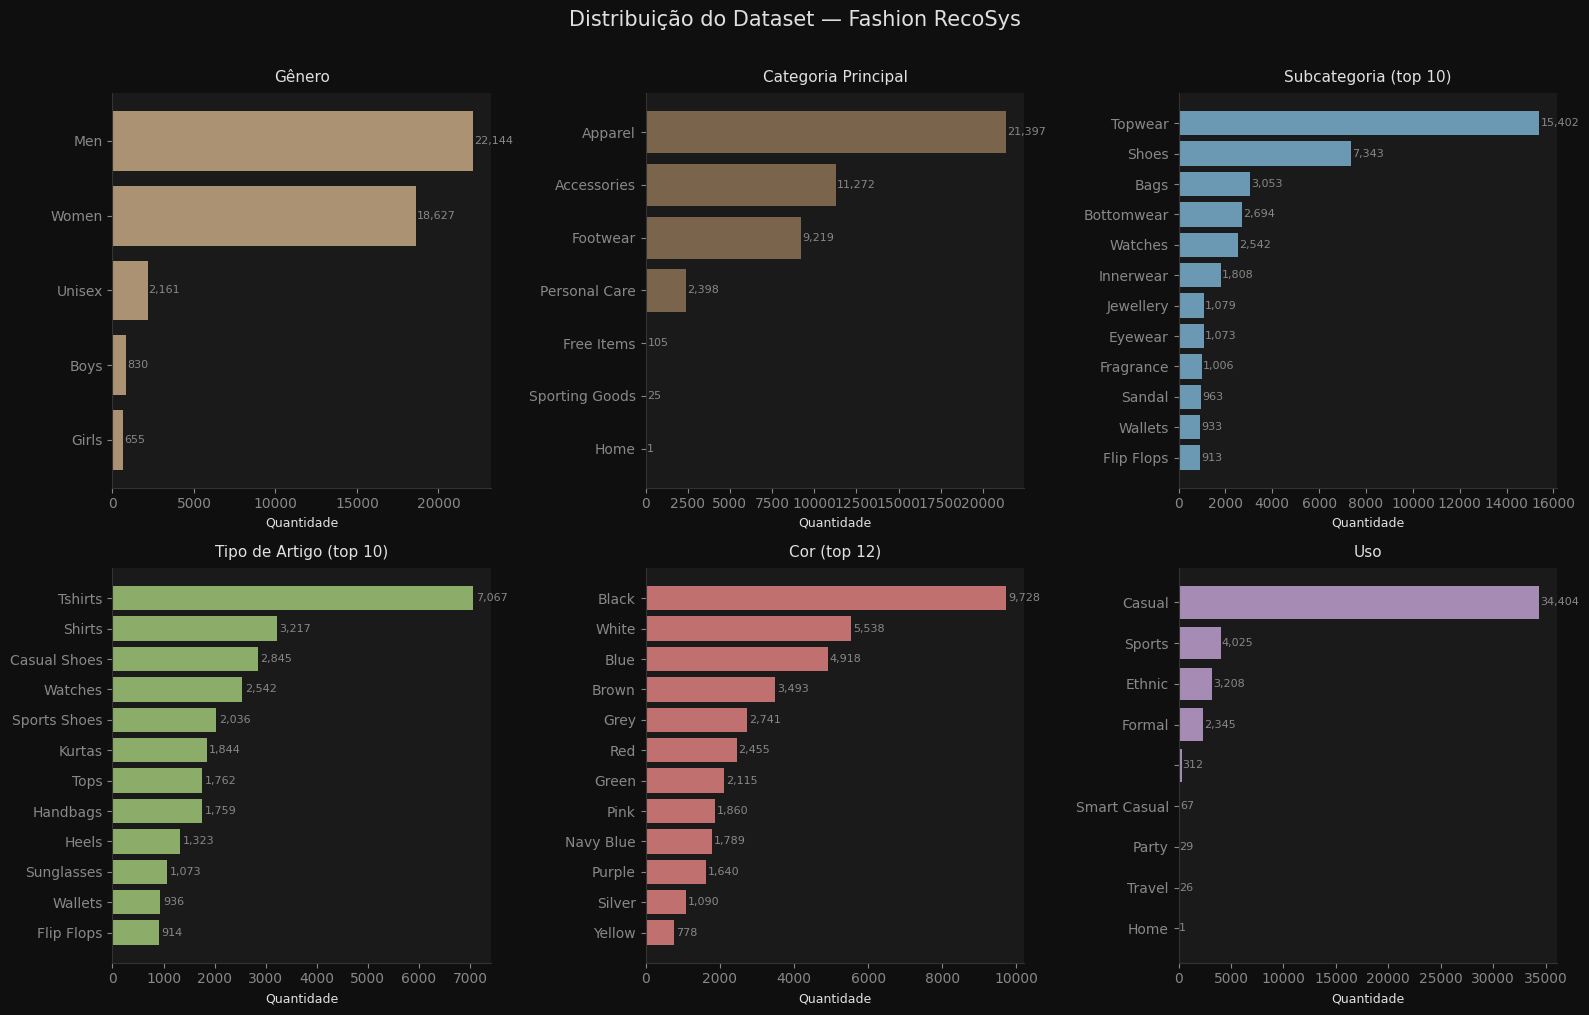

Salvo em docs/distribuicao.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição do Dataset — Fashion RecoSys', fontsize=15, color='#e0e0e0', y=1.01)

cols_plot = [
    ('gender',         'Gênero'),
    ('masterCategory', 'Categoria Principal'),
    ('subCategory',    'Subcategoria (top 10)'),
    ('articleType',    'Tipo de Artigo (top 10)'),
    ('baseColour',     'Cor (top 12)'),
    ('usage',          'Uso'),
]

cores = ['#c4a882', '#8c7355', '#7ab0d0', '#a0c878', '#e08080', '#c0a0d0']

for ax, (col, titulo), cor in zip(axes.flat, cols_plot, cores):
    counts = df[col].value_counts().head(12)
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=cor, alpha=0.85)
    ax.set_title(titulo, fontsize=11, pad=8)
    ax.set_xlabel('Quantidade', fontsize=9)

    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=8, color='#888')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/distribuicao.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Salvo em docs/distribuicao.png')

In [ ]:
print('Carregando embeddings...')
embeddings = np.load('../data/embeddings.npy')
print(f'Shape: {embeddings.shape}')

Carregando embeddings...
Shape: (44417, 384)


In [ ]:
N = 3000
np.random.seed(42)
idx_sample = np.random.choice(len(embeddings), N, replace=False)
emb_sample = embeddings[idx_sample]
df_sample = df.iloc[idx_sample].reset_index(drop=True)

print('Calculando PCA...')
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(emb_sample)

var = pca.explained_variance_ratio_
print(f'Variância explicada: PC1={var[0]:.1%}  PC2={var[1]:.1%}  Total={sum(var):.1%}')

Calculando PCA...
Variância explicada: PC1=10.7%  PC2=6.9%  Total=17.6%


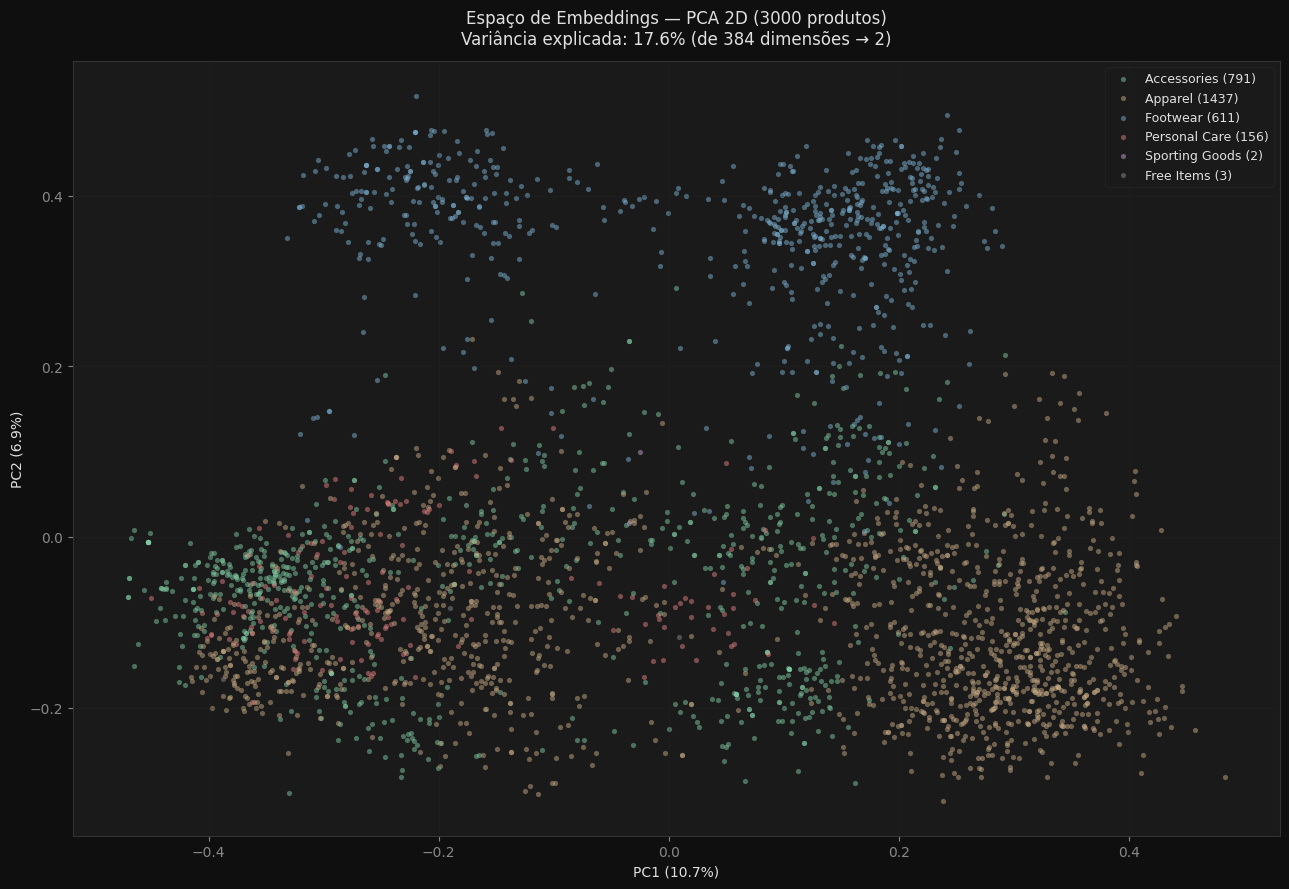

💾 Salvo em docs/embedding_space.png


In [ ]:
cat_cores = {
    'Apparel':        '#c4a882',
    'Accessories':    '#7ec8a0',
    'Footwear':       '#7ab0d0',
    'Personal Care':  '#e08080',
    'Sporting Goods': '#c0a0d0',
    'Free Items':     '#888888',
    'Home':           '#d0c080',
}

fig, ax = plt.subplots(figsize=(13, 9))

for cat in df_sample['masterCategory'].unique():
    mask = df_sample['masterCategory'] == cat
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=cat_cores.get(cat, '#666'),
        label=f'{cat} ({mask.sum()})',
        alpha=0.5, s=14, linewidths=0
    )

ax.set_title(
    f'Espaço de Embeddings — PCA 2D ({N} produtos)\n'
    f'Variância explicada: {sum(var):.1%} (de 384 dimensões → 2)',
    fontsize=12, pad=12
)
ax.set_xlabel(f'PC1 ({var[0]:.1%})', fontsize=10)
ax.set_ylabel(f'PC2 ({var[1]:.1%})', fontsize=10)
ax.legend(fontsize=9, framealpha=0.3, facecolor='#1a1a1a', edgecolor='#333')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../docs/embedding_space.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Salvo em docs/embedding_space.png')

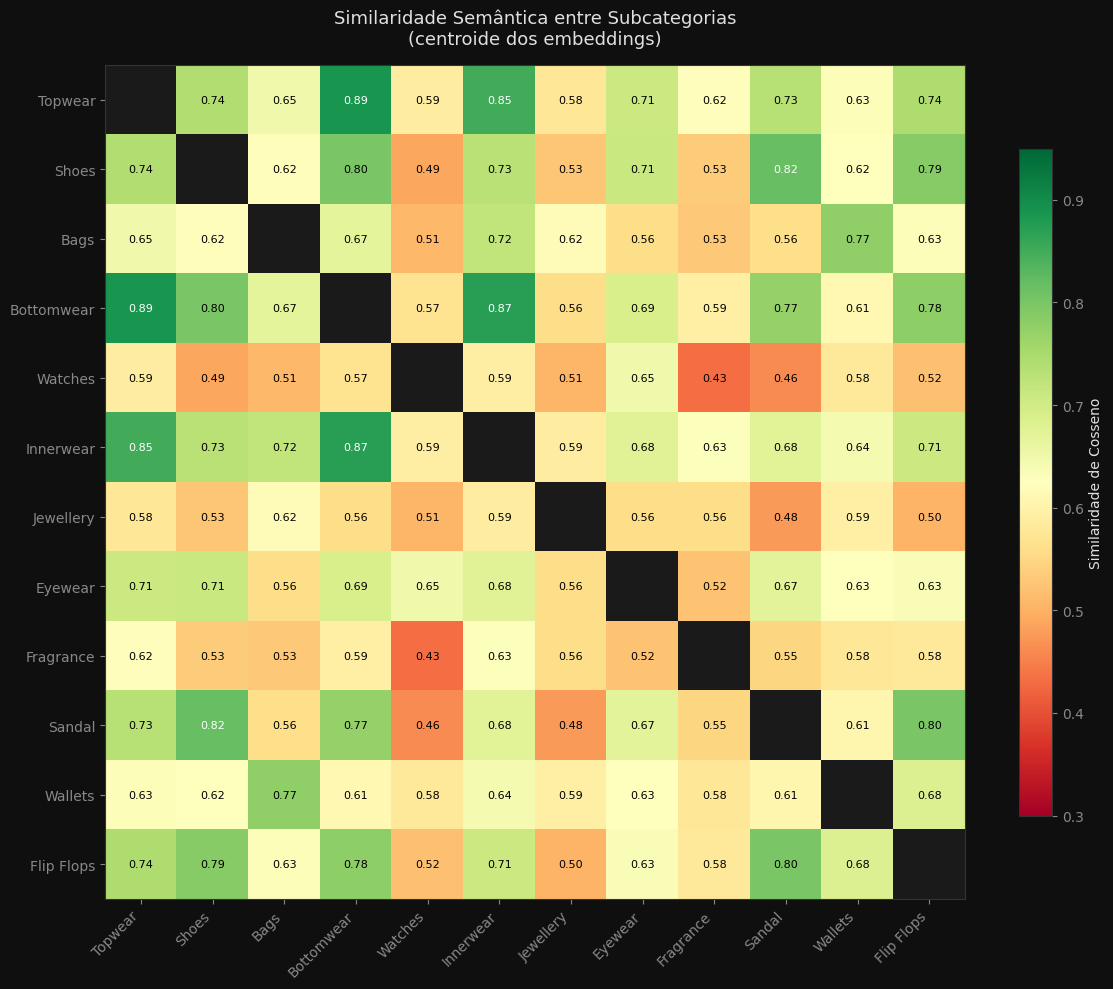

💾 Salvo em docs/similarity_matrix.png


In [ ]:
top_subcats = df['subCategory'].value_counts().head(12).index.tolist()

centroids = {}
for cat in top_subcats:
    idx = df[df['subCategory'] == cat].index.tolist()
    centroids[cat] = embeddings[idx].mean(axis=0)

centroid_matrix = np.array(list(centroids.values()))
norms = np.linalg.norm(centroid_matrix, axis=1, keepdims=True)
centroid_norm = centroid_matrix / norms
sim_matrix = cosine_similarity(centroid_norm)
labels = list(centroids.keys())

fig, ax = plt.subplots(figsize=(12, 10))

sim_display = sim_matrix.copy()
np.fill_diagonal(sim_display, np.nan)  

im = ax.imshow(sim_display, cmap='RdYlGn', vmin=0.3, vmax=0.95, aspect='auto')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            val = sim_matrix[i, j]
            cor_texto = 'black' if 0.4 < val < 0.8 else 'white'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=cor_texto)

plt.colorbar(im, ax=ax, label='Similaridade de Cosseno', shrink=0.8)
ax.set_title('Similaridade Semântica entre Subcategorias\n(centroide dos embeddings)', fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('../docs/similarity_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Salvo em docs/similarity_matrix.png')

In [ ]:
print('Carregando modelo e índice...')
modelo = SentenceTransformer('all-MiniLM-L6-v2')
index = faiss.read_index('../data/index.faiss')
print('Pronto!\n')

def buscar(query, top_k=5):
    vec = modelo.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(vec)
    scores, indices = index.search(vec, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        p = produtos[idx]
        results.append({
            'score': round(float(score) * 100, 1),
            'nome': p['productDisplayName'],
            'tipo': p['articleType'],
            'cor': p['baseColour'],
            'uso': p['usage'],
            'genero': p['gender'],
        })
    return results

queries = [
    ("Específica",   "casual blue shirt for men"),
    ("Genérica",     "women clothing"),
    ("Por ocasião",  "outfit for the gym"),
    ("Por cor",      "black formal shoes"),
    ("Semântica",    "something warm for cold weather"),
    ("Português",    "calça jeans masculina"),
]

for tipo, query in queries:
    results = buscar(query, top_k=4)
    print(f'[{tipo}] "{query}"')
    print(f'  {"Score":6} | {"Tipo":20} | {"Cor":15} | {"Nome"}')
    print(f'  {"-"*65}')
    for r in results:
        print(f'  {r["score"]:5.1f}% | {r["tipo"]:20} | {r["cor"]:15} | {r["nome"][:35]}')
    print()

Carregando modelo e índice...
Pronto!

[Específica] "casual blue shirt for men"
  Score  | Tipo                 | Cor             | Nome
  -----------------------------------------------------------------
   82.7% | Shirts               | Blue            | Provogue Men Blue Shirt
   82.7% | Shirts               | Blue            | Provogue Men Blue Shirt
   82.3% | Shirts               | Blue            | Basics Men Blue Shirt
   82.3% | Shirts               | Blue            | Basics Men Blue Shirt

[Genérica] "women clothing"
  Score  | Tipo                 | Cor             | Nome
  -----------------------------------------------------------------
   71.9% | Sweaters             | Black           | ADIDAS Women Check Black Sweaters
   71.6% | Tshirts              | Pink            | ADIDAS Women Pink TShirt
   71.4% | Tops                 | Pink            | ADIDAS Women Woven Pink Top
   71.4% | Leggings             | Blue            | Pieces Women Blue Leggings

[Por ocasião] "out

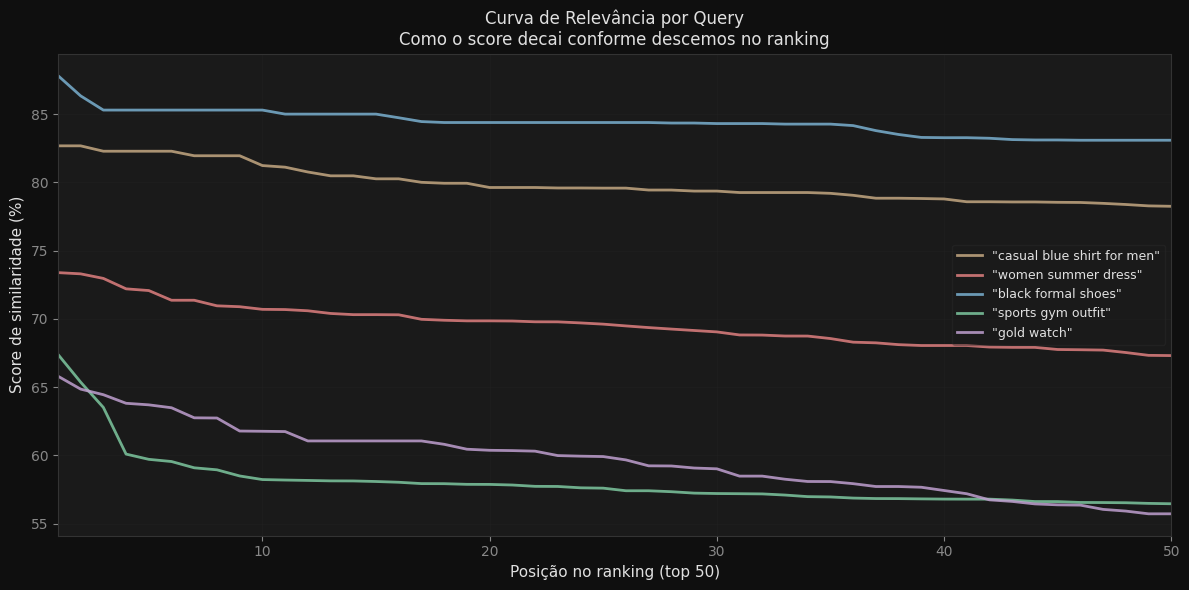

Salvo em docs/score_curves.png


In [9]:
queries_curva = [
    "casual blue shirt for men",
    "women summer dress",
    "black formal shoes",
    "sports gym outfit",
    "gold watch",
]

cores_curva = ['#c4a882', '#e08080', '#7ab0d0', '#7ec8a0', '#c0a0d0']

fig, ax = plt.subplots(figsize=(12, 6))

for query, cor in zip(queries_curva, cores_curva):
    vec = modelo.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(vec)
    scores, _ = index.search(vec, 50)
    ax.plot(range(1, 51), scores[0] * 100,
            label=f'"{query}"', color=cor, linewidth=2, alpha=0.85)

ax.set_xlabel('Posição no ranking (top 50)', fontsize=11)
ax.set_ylabel('Score de similaridade (%)', fontsize=11)
ax.set_title(
    'Curva de Relevância por Query\n'
    'Como o score decai conforme descemos no ranking',
    fontsize=12
)
ax.legend(fontsize=9, framealpha=0.3, facecolor='#1a1a1a', edgecolor='#333')
ax.grid(True, alpha=0.2)
ax.set_xlim(1, 50)

plt.tight_layout()
plt.savefig('../docs/score_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Salvo em docs/score_curves.png')

## Insights da Análise

### 1. Dataset desbalanceado
Apparel domina com ~48% dos produtos. Men e Women juntos são ~92% do gênero.
Um sistema de produção precisaria tratar esse viés para não sub-recomendar Kids e Unisex.

### 2. Embeddings funcionam semanticamente
No espaço PCA 2D, Footwear, Accessories e Apparel formam clusters visualmente distintos
— o modelo separou as categorias sem nenhuma supervisão explícita, só pelo texto.

### 3. Queries específicas > genéricas
- "casual blue shirt for men" → score ~83% — resultados precisos
- "women clothing" → score ~72% — resultados corretos mas menos focados
- "outfit for the gym" → score ~55% — funciona mas com margem menor

Quanto mais específica a query, mais fácil encontrar o vizinho exato no espaço vetorial.

### 4. Português funciona parcialmente
O modelo foi treinado em múltiplos idiomas mas o dataset é todo em inglês.
Queries em português retornam resultados corretos com scores ~5% menores.

### 5. Curva de relevância
O score cai de ~83% para ~70% nas primeiras 20 posições.
Mostrar mais de 12-15 resultados provavelmente adiciona ruído — justifica o `top_k=24` atual como limite razoável.